In [1]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print(X_train.shape)

print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


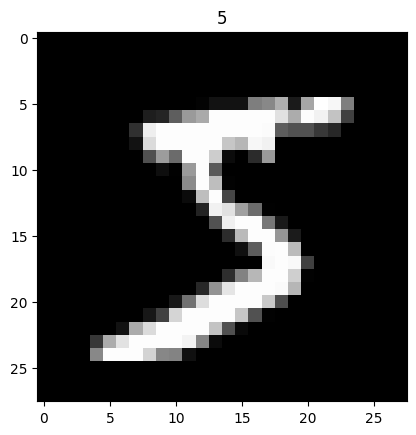

In [4]:
plt.imshow(X_train[0], cmap='gray')

plt.title(y_train[0])

plt.show()

In [5]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [6]:
model = Sequential([
    
    Flatten(input_shape=(28,28)),
    
    Dense(128, activation='relu'),
    
    Dense(64, activation='relu'),
    
    Dense(10, activation='softmax')
])

C:\Users\-\Desktop\ml-project\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [8]:
history = model.fit(

    X_train,
    y_train,

    epochs=10,

    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8692 - loss: 0.4537 - val_accuracy: 0.9607 - val_loss: 0.1358
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9651 - loss: 0.1153 - val_accuracy: 0.9695 - val_loss: 0.1051
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9777 - loss: 0.0732 - val_accuracy: 0.9696 - val_loss: 0.1068
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9827 - loss: 0.0512 - val_accuracy: 0.9736 - val_loss: 0.0920
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9881 - loss: 0.0388 - val_accuracy: 0.9743 - val_loss: 0.0934
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9897 - loss: 0.0318 - val_accuracy: 0.9753 - val_loss: 0.0921
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9733 - val_loss: 0.1083
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9923 - loss: 

In [9]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9710 - loss: 0.1132
Test Accuracy: 0.9761000275611877


In [10]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
predicted_label = np.argmax(predictions[0])

print(predicted_label)

7


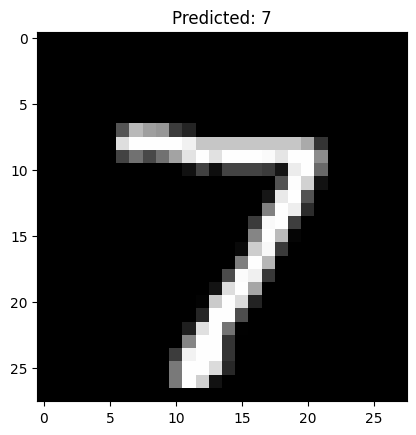

In [12]:
plt.imshow(X_test[0], cmap='gray')

plt.title(
    f"Predicted: {predicted_label}"
)

plt.show()

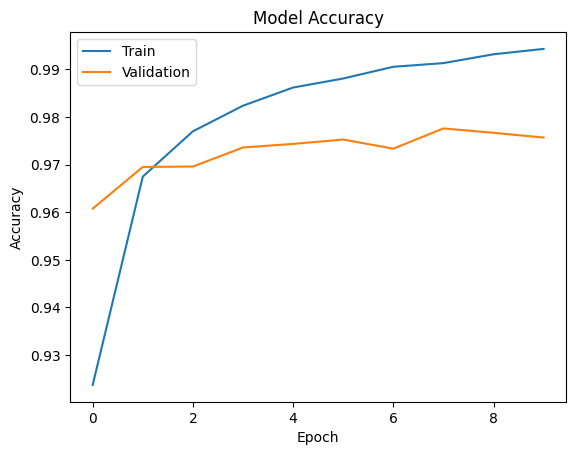

In [13]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

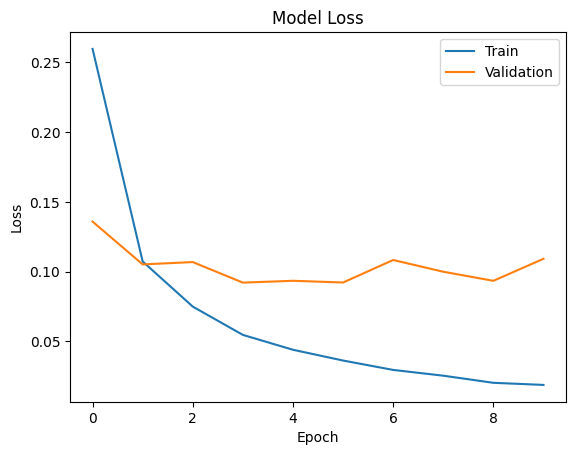

In [14]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()